## API setup

In [1]:
import torch
import numpy as np
import random
import numpy as np
import re
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [2]:
#devi installare il dataset però prima 
from nas_201_api import NASBench201API as API
#loading api 
api = API(
    r'datasets\NAS-Bench-201-v1_1-096897.pth',
    verbose=False
)

print(len(api))

15625


In [3]:

seed = 42

# Python random
random.seed(seed)

# NumPy
np.random.seed(seed)

# PyTorch CPU
torch.manual_seed(seed)

# PyTorch GPU (se usi CUDA)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# per riproducibilità più forte (può rallentare)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

## API inspection 

un elemento del dataset:
- DAG dell'architettura in cui ogni nodo è una cella di operazioni (conv, max pooling..)
- risultati su vari datasets e su regime brene e lungo di training 

In [4]:
api.show(1)

>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> 012 epochs >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
|nor_conv_3x3~0|+|nor_conv_3x3~0|avg_pool_3x3~1|+|skip_connect~0|nor_conv_3x3~1|skip_connect~2|
datasets : ['cifar10-valid', 'cifar10', 'cifar100', 'ImageNet16-120'], extra-info : None
cifar10-valid  FLOP=113.95 M, Params=0.802 MB, latency=16.85 ms.
cifar10-valid  train : [loss = 0.382, top1 = 86.97%], valid : [loss = 0.514, top1 = 82.83%]
cifar10        FLOP=113.95 M, Params=0.802 MB, latency=16.85 ms.
cifar10        train : [loss = 0.243, top1 = 91.69%], test  : [loss = 0.362, top1 = 88.22%]
cifar100       FLOP=113.96 M, Params=0.808 MB, latency=15.36 ms.
cifar100       train : [loss = 1.271, top1 = 63.76%], valid : [loss = 1.495, top1 = 57.80%], test : [loss = 1.478, top1 = 58.26%]
ImageNet16-120 FLOP= 28.50 M, Params=0.810 MB, latency=13.77 ms.
ImageNet16-120 train : [loss = 2.548, top1 = 35.41%], valid : [loss = 2.580, top1 = 35.43%], test : [loss = 2.611, top1 = 33.80%]
>>>>>>>>>>>>>>>>>>

La stringa **|nor_conv_3x3~0|+|nor_conv_3x3~0|avg_pool_3x3~1|+|skip_connect~0|nor_conv_3x3~1|skip_connect~2|**
- node-0: the input tensor
- node-1: conv-3x3( node-0 )
- node-2: conv-3x3( node-0 ) + avg-pool-3x3( node-1 )
- node-3: skip-connect( node-0 ) + conv-3x3( node-1 ) + skip-connect( node-2 )

per vedere risultati su un datasets e una specifica architettura 

In [5]:
# show the mean loss and accuracy of an architecture
info = api.query_meta_info_by_index(1)  # This is an instance of `ArchResults`
res_metrics = info.get_metrics('cifar10', 'train') # This is a dict with metric names as keys

# get the detailed information
results = api.query_by_index(1, 'cifar100') # a dict of all trials for 1st net on cifar100, where the key is the seed
print ('There are {:} trials for this architecture [{:}] on cifar100'.format(len(results), api[1]))
for seed, result in results.items():
  print ('Latency : {:}'.format(result.get_latency()))
  print ('Train Info : {:}'.format(result.get_train()))
  print ('Valid Info : {:}'.format(result.get_eval('x-valid')))
  print ('Test  Info : {:}'.format(result.get_eval('x-test')))
  # for the metric after a specific epoch
  print ('Train Info [10-th epoch] : {:}'.format(result.get_train(10)))

There are 1 trials for this architecture [|nor_conv_3x3~0|+|nor_conv_3x3~0|avg_pool_3x3~1|+|skip_connect~0|nor_conv_3x3~1|skip_connect~2|] on cifar100
Latency : 0.015363384176183631
Train Info : {'iepoch': 11, 'loss': 1.2711473697662354, 'accuracy': 63.756, 'cur_time': 21.69641375541687, 'all_time': 260.35696506500244}
Valid Info : {'iepoch': 11, 'loss': 1.495258326148987, 'accuracy': 57.79999996948242, 'cur_time': 0.7508397953850883, 'all_time': 9.01007754462106}
Test  Info : {'iepoch': 11, 'loss': 1.477725588607788, 'accuracy': 58.25999995727539, 'cur_time': 0.7508397953850883, 'all_time': 9.01007754462106}
Train Info [10-th epoch] : {'iepoch': 10, 'loss': 1.3365458668136596, 'accuracy': 61.568, 'cur_time': 21.69641375541687, 'all_time': 238.66055130958557}


tokenizzazione del tipo: 
asse 0 → tipo di operazione
asse 1 → nodo sorgente
asse 2 → nodo destinazione

In [6]:
api[0]

'|avg_pool_3x3~0|+|nor_conv_1x1~0|skip_connect~1|+|nor_conv_1x1~0|skip_connect~1|skip_connect~2|'

In [7]:


# mapping operazioni → indice tensor
OPS = {
    'nor_conv_3x3': 0,
    'nor_conv_1x1': 1,
    'skip_connect': 2,
    'avg_pool_3x3': 3
}

def arch_to_tensor(arch_str):
    """
    Converte una stringa NAS-Bench-201 in:

        A[operation, i, j]

    shape:
        [num_ops, num_nodes, num_nodes]
    """

    # separa i nodi
    nodes = arch_str.split('+')

    # numero totale nodi
    # input + nodi intermedi
    N = len(nodes) + 1

    K = len(OPS)

    # adjacency tensor
    A = np.zeros((K, N, N), dtype=np.float32)

    # parse
    for dst, node in enumerate(nodes, start=1):

        # trova edge tipo:
        # nor_conv_3x3~0
        edges = re.findall(
            r'(nor_conv_3x3|nor_conv_1x1|skip_connect|avg_pool_3x3)~(\d)',
            node
        )

        for op_name, src in edges:

            src = int(src)

            op_idx = OPS[op_name]

            A[op_idx, src, dst] = 1.0

    return A

In [8]:
arch_to_tensor(arch_str=api[0])


array([[[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]],

       [[0., 0., 1., 1.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]],

       [[0., 0., 0., 0.],
        [0., 0., 1., 1.],
        [0., 0., 0., 1.],
        [0., 0., 0., 0.]],

       [[0., 1., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]]], dtype=float32)

In [9]:

all_tensors = []

for i in range(len(api)):

    arch_str = api[i]

    A = arch_to_tensor(arch_str)

    all_tensors.append(A)

X = np.stack(all_tensors)
X.shape

(15625, 4, 4, 4)

In [10]:

X = torch.tensor(X)
X.shape

torch.Size([15625, 4, 4, 4])

In [11]:
X = X.view(len(X), -1)
X.shape

torch.Size([15625, 64])

In [12]:


LATENT_DIM = 16
INPUT_DIM = 64


class VAE(nn.Module):

    def __init__(self):

        super().__init__()

        # encoder
        self.fc1 = nn.Linear(INPUT_DIM, 128)
        self.fc2 = nn.Linear(128, 64)

        self.mu = nn.Linear(64, LATENT_DIM)
        self.logvar = nn.Linear(64, LATENT_DIM)

        # decoder
        self.fc3 = nn.Linear(LATENT_DIM, 64)
        self.fc4 = nn.Linear(64, 128)
        self.fc5 = nn.Linear(128, INPUT_DIM)

    def encode(self, x):

        h = F.relu(self.fc1(x))
        h = F.relu(self.fc2(h))

        return self.mu(h), self.logvar(h)

    def reparameterize(self, mu, logvar):

        std = torch.exp(0.5 * logvar)

        eps = torch.randn_like(std)

        return mu + eps * std

    def decode(self, z):

        h = F.relu(self.fc3(z))
        h = F.relu(self.fc4(h))

        return torch.sigmoid(self.fc5(h))

    def forward(self, x):

        mu, logvar = self.encode(x)

        z = self.reparameterize(mu, logvar)

        recon = self.decode(z)

        return recon, mu, logvar

In [13]:


def vae_loss(recon, x, mu, logvar,beta=1):

    # ricostruzione
    recon_loss = F.binary_cross_entropy(
        recon,
        x,
        reduction='sum'
    )

    # KL divergence
    kl = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    return recon_loss + kl * beta

In [14]:


dataset = TensorDataset(X)

loader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=True
)

In [15]:
model = VAE()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

epochs = 50

model.train()

for epoch in range(epochs):

    total_loss = 0

    for batch in loader:

        x = batch[0]

        # forward
        recon, mu, logvar = model(x)

        loss = vae_loss(recon, x, mu, logvar,beta=1.3)

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} | Loss: {total_loss:.2f}")

Epoch 1 | Loss: 277800.17
Epoch 2 | Loss: 190077.46
Epoch 3 | Loss: 189450.74
Epoch 4 | Loss: 189232.10
Epoch 5 | Loss: 189018.13
Epoch 6 | Loss: 188937.55
Epoch 7 | Loss: 188763.41
Epoch 8 | Loss: 188685.00
Epoch 9 | Loss: 188511.17
Epoch 10 | Loss: 188474.99
Epoch 11 | Loss: 188356.48
Epoch 12 | Loss: 188402.74
Epoch 13 | Loss: 188219.33
Epoch 14 | Loss: 188168.45
Epoch 15 | Loss: 188200.12
Epoch 16 | Loss: 188108.41
Epoch 17 | Loss: 188061.01
Epoch 18 | Loss: 188047.01
Epoch 19 | Loss: 188082.32
Epoch 20 | Loss: 188119.35
Epoch 21 | Loss: 187984.86
Epoch 22 | Loss: 188021.21
Epoch 23 | Loss: 188038.50
Epoch 24 | Loss: 187938.22
Epoch 25 | Loss: 187949.24
Epoch 26 | Loss: 187939.07
Epoch 27 | Loss: 187906.65
Epoch 28 | Loss: 187922.02
Epoch 29 | Loss: 187903.78
Epoch 30 | Loss: 187878.15
Epoch 31 | Loss: 187890.58
Epoch 32 | Loss: 187869.45
Epoch 33 | Loss: 187902.87
Epoch 34 | Loss: 187889.07
Epoch 35 | Loss: 187820.53
Epoch 36 | Loss: 187856.29
Epoch 37 | Loss: 187801.88
Epoch 38 |

In [16]:

model.eval()

with torch.no_grad():

    mu, logvar = model.encode(X)

    z = mu   # embedding stabile
z = z.numpy()  # embedding del VAE
z.shape


pca = PCA(n_components=2)
z_2d = pca.fit_transform(z)


In [17]:
acc = np.zeros(len(api))
for i in range(len(api)):
    acc[i] = api.get_more_info(i, dataset='cifar10')['test-accuracy']

plottiamo lo spazio latente per vedere la correlazione tra posizione nello spazio latente dell'architettura e accruacy 

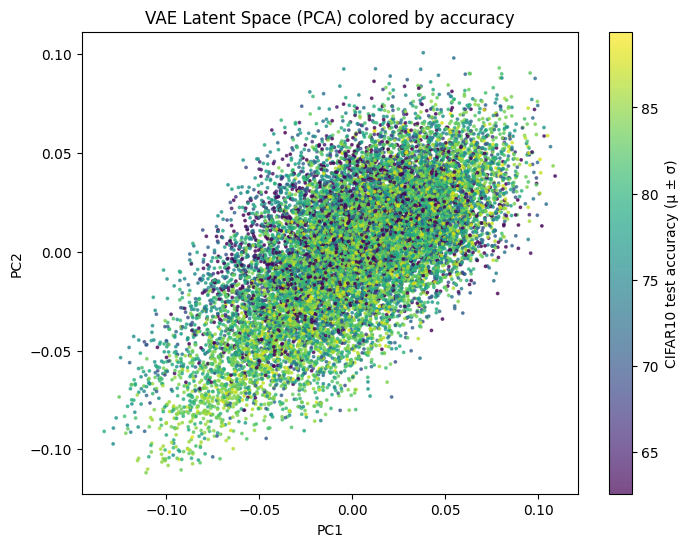

In [18]:

acc = np.array(acc)

mu = np.mean(acc)
std = np.std(acc)

vmin = mu - std
vmax = mu + std

# ----------------------------
# 4. PLOT
# ----------------------------
plt.figure(figsize=(8,6))

sc = plt.scatter(
    z[:, 0],
    z[:, 1],
    c=acc,
    cmap='viridis',
    s=3,
    alpha=0.7,
    vmin=vmin,
    vmax=vmax
)

plt.colorbar(sc, label="CIFAR10 test accuracy (μ ± σ)")

plt.title("VAE Latent Space (PCA) colored by accuracy")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

### interpolazione tra due punti 

In [19]:
print(acc)

[69.55 88.22 69.95 ... 84.09 52.62 66.67]


In [20]:
#interpolazione tra due punto dello spazio latente per ottenere idealmente un punto in mezzo con accuracy a metà
z_worst = z[-2]
z_best  = z[1]

print(acc[0])
print(acc[1])

print(z_worst.shape) 

69.55
88.22
(16,)


In [21]:
n_steps = 5

interpolated_z = []

for t in np.linspace(0, 1, n_steps):

    z_t = (1 - t) * z_worst + t * z_best

    interpolated_z.append(z_t)

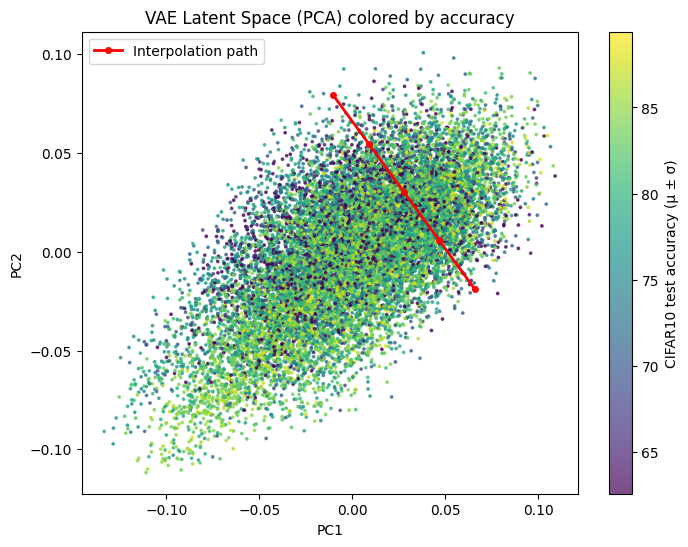

In [22]:
interp_z = np.array([z_t for z_t in interpolated_z])
interp_2d = pca.transform(interp_z)

plt.figure(figsize=(8,6))

sc = plt.scatter(
    z[:, 0],
    z[:, 1],
    c=acc,
    cmap='viridis',
    s=3,
    alpha=0.7,
    vmin=vmin,
    vmax=vmax
)

plt.plot(
    interp_2d[:, 0],
    interp_2d[:, 1],
    color='red',
    linewidth=2,
    marker='o',
    markersize=4,
    label='Interpolation path'
)
plt.colorbar(sc, label="CIFAR10 test accuracy (μ ± σ)")

plt.title("VAE Latent Space (PCA) colored by accuracy")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.legend()
plt.show()

In [23]:
z_tensore = torch.tensor(interpolated_z)
print(z_tensore.shape)

torch.Size([5, 16])


C:\Users\tiber\AppData\Local\Temp\ipykernel_23432\2794888997.py:1: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ..\torch\csrc\utils\tensor_new.cpp:264.)
  z_tensore = torch.tensor(interpolated_z)


In [24]:

pred = model.decode(z_tensore[1])
print(pred)

tensor([2.7962e-05, 2.0653e-01, 1.9816e-01, 1.9894e-01, 3.3685e-05, 3.1987e-05,
        1.8894e-01, 2.1827e-01, 3.9403e-05, 3.5673e-05, 3.3629e-05, 1.9800e-01,
        4.1391e-05, 3.5590e-05, 4.2527e-05, 3.6618e-05, 4.6613e-05, 1.9726e-01,
        1.9925e-01, 1.8769e-01, 3.9723e-05, 3.1682e-05, 2.0340e-01, 2.0602e-01,
        3.4068e-05, 4.0182e-05, 3.7196e-05, 2.0289e-01, 3.7771e-05, 3.5910e-05,
        4.0835e-05, 4.0680e-05, 4.7193e-05, 1.9115e-01, 1.9683e-01, 1.9153e-01,
        4.8901e-05, 3.6276e-05, 1.9880e-01, 1.8477e-01, 3.5251e-05, 3.5290e-05,
        4.1407e-05, 2.0936e-01, 4.5892e-05, 3.5777e-05, 3.2689e-05, 3.7317e-05,
        3.7331e-05, 2.1403e-01, 1.9988e-01, 1.9772e-01, 4.4082e-05, 2.7891e-05,
        1.9858e-01, 2.0025e-01, 4.3774e-05, 4.4783e-05, 3.9550e-05, 1.9559e-01,
        4.3891e-05, 3.4260e-05, 3.8717e-05, 3.1609e-05],
       grad_fn=<SigmoidBackward0>)


In [25]:
pred.shape

torch.Size([64])

In [26]:
num_ops = 4
arch= pred.view(4, 4, 4)

In [27]:
print(arch)

tensor([[[2.7962e-05, 2.0653e-01, 1.9816e-01, 1.9894e-01],
         [3.3685e-05, 3.1987e-05, 1.8894e-01, 2.1827e-01],
         [3.9403e-05, 3.5673e-05, 3.3629e-05, 1.9800e-01],
         [4.1391e-05, 3.5590e-05, 4.2527e-05, 3.6618e-05]],

        [[4.6613e-05, 1.9726e-01, 1.9925e-01, 1.8769e-01],
         [3.9723e-05, 3.1682e-05, 2.0340e-01, 2.0602e-01],
         [3.4068e-05, 4.0182e-05, 3.7196e-05, 2.0289e-01],
         [3.7771e-05, 3.5910e-05, 4.0835e-05, 4.0680e-05]],

        [[4.7193e-05, 1.9115e-01, 1.9683e-01, 1.9153e-01],
         [4.8901e-05, 3.6276e-05, 1.9880e-01, 1.8477e-01],
         [3.5251e-05, 3.5290e-05, 4.1407e-05, 2.0936e-01],
         [4.5892e-05, 3.5777e-05, 3.2689e-05, 3.7317e-05]],

        [[3.7331e-05, 2.1403e-01, 1.9988e-01, 1.9772e-01],
         [4.4082e-05, 2.7891e-05, 1.9858e-01, 2.0025e-01],
         [4.3774e-05, 4.4783e-05, 3.9550e-05, 1.9559e-01],
         [4.3891e-05, 3.4260e-05, 3.8717e-05, 3.1609e-05]]],
       grad_fn=<ViewBackward0>)


In [28]:
binary = torch.zeros_like(arch)

for i in range(4):
    idx = pred[i].view(-1).argmax()
    r, c = divmod(idx.item(), 4)
    binary[i, r, c] = 1

print(binary)

tensor([[[1., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]],

        [[1., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]],

        [[1., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]],

        [[1., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]]])


### predicting accuracy 

In [29]:
print(X.shape)

acc = (acc - acc.min()) / (acc.max() - acc.min())
acc_tensor = torch.as_tensor(acc, dtype=torch.float32)
print(acc_tensor.shape)

torch.Size([15625, 64])
torch.Size([15625])


In [30]:
dataset = TensorDataset(X,acc_tensor)

loader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=True
)

In [31]:

# regressore semplice
model = nn.Sequential(
    nn.Linear(X.shape[1], 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 1)
)

loss_fn = nn.MSELoss()
opt = torch.optim.Adam(model.parameters(), lr=1e-4)

# training loop
for epoch in range(100):
    for xb, yb in loader:
        pred = model(xb)
        loss = loss_fn(pred, yb)

        opt.zero_grad()
        loss.backward()
        opt.step()

    print(f"Epoch {epoch} | Loss {loss.item():.4f}")

c:\Users\tiber\Desktop\em\ALife\venv\Lib\site-packages\torch\nn\modules\loss.py:535: UserWarning: Using a target size (torch.Size([128])) that is different to the input size (torch.Size([128, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
c:\Users\tiber\Desktop\em\ALife\venv\Lib\site-packages\torch\nn\modules\loss.py:535: UserWarning: Using a target size (torch.Size([9])) that is different to the input size (torch.Size([9, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 0 | Loss 0.1451
Epoch 1 | Loss 0.0173
Epoch 2 | Loss 0.0991
Epoch 3 | Loss 0.0213
Epoch 4 | Loss 0.0128
Epoch 5 | Loss 0.0898
Epoch 6 | Loss 0.0435
Epoch 7 | Loss 0.0166
Epoch 8 | Loss 0.0190
Epoch 9 | Loss 0.0064
Epoch 10 | Loss 0.0074
Epoch 11 | Loss 0.0143
Epoch 12 | Loss 0.0354
Epoch 13 | Loss 0.0189
Epoch 14 | Loss 0.0890
Epoch 15 | Loss 0.0068
Epoch 16 | Loss 0.0036
Epoch 17 | Loss 0.0230
Epoch 18 | Loss 0.0068
Epoch 19 | Loss 0.0039
Epoch 20 | Loss 0.0097
Epoch 21 | Loss 0.0044
Epoch 22 | Loss 0.1588
Epoch 23 | Loss 0.0075
Epoch 24 | Loss 0.0098
Epoch 25 | Loss 0.0077
Epoch 26 | Loss 0.0104
Epoch 27 | Loss 0.0330
Epoch 28 | Loss 0.0133
Epoch 29 | Loss 0.0265
Epoch 30 | Loss 0.0119
Epoch 31 | Loss 0.0060
Epoch 32 | Loss 0.0844
Epoch 33 | Loss 0.0201
Epoch 34 | Loss 0.0403
Epoch 35 | Loss 0.0246
Epoch 36 | Loss 0.0152
Epoch 37 | Loss 0.0212
Epoch 38 | Loss 0.0129
Epoch 39 | Loss 0.0097
Epoch 40 | Loss 0.0066
Epoch 41 | Loss 0.0077
Epoch 42 | Loss 0.0196
Epoch 43 | Loss 0.007

In [32]:
model.eval()

x = binary.float().view(1, -1)   # shape [1, 64]

with torch.no_grad():
    pred = model(x).squeeze()

print(pred.item())

0.8989077210426331


- interpolazione tra due modelli per vedere architettura in mezzo che performance ha 
- altri modi per codificare la matrice dell'architettura e la loss dello spazio latente 